### Data Preprocessing

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
df=pd.read_csv("imblanced_dataset.csv")

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       2000 non-null   int64  
 1   age               1954 non-null   float64
 2   income            1940 non-null   float64
 3   city              1965 non-null   object 
 4   education         1970 non-null   object 
 5   experience_years  1959 non-null   float64
 6   employment_type   1965 non-null   object 
 7   credit_score      1945 non-null   float64
 8   loan_amount       1950 non-null   float64
 9   default           2000 non-null   object 
dtypes: float64(5), int64(1), object(4)
memory usage: 156.4+ KB


In [82]:
df.describe()

,customer_id,age,income,experience_years,credit_score,loan_amount
count,2000.000000,1954.000000,1940.000000,1959.000000,1945.000000,1.950000e+03
mean,100999.610000,36.039918,66369.206701,13.426238,697.694087,5.302056e+04
std,578.466548,11.560409,58354.463905,9.418840,71.446133,1.916440e+05
min,100001.000000,18.000000,10450.000000,0.000000,50.000000,1.000000e+03
25%,100498.750000,29.000000,37227.000000,6.000000,652.000000,1.980050e+04
50%,100998.500000,35.000000,54817.000000,13.000000,699.000000,3.509250e+04
75%,101501.250000,42.000000,79697.750000,20.000000,743.000000,5.767750e+04
max,102000.000000,150.000000,1000000.000000,50.000000,1100.000000,5.000000e+06


In [83]:
df.dtypes

customer_id           int64
age                 float64
income              float64
city                 object
education            object
experience_years    float64
employment_type      object
credit_score        float64
loan_amount         float64
default              object
dtype: object

In [84]:
df.duplicated().sum()

np.int64(12)

In [85]:
df=df.drop_duplicates()

In [86]:
df.isnull().sum()

customer_id          0
age                 45
income              59
city                35
education           30
experience_years    40
employment_type     35
credit_score        55
loan_amount         50
default              0
dtype: int64

In [109]:
# cleaning the categorical columns
cat_cols=["city","education","employment_type"]

for col in cat_cols:
    df[col]=df[col].astype("string").str.strip().str.title()


# handel the misisng values

for cols in cat_cols:
    df[col]=df[col].fillna(df[col].mode()[0])


for col in cat_cols:
    df[col]=df[col].astype("object").fillna("Unknown")

In [110]:
# handeling te invalid values

df.loc[(df["age"]<18)|(df["age"]>100),"age"]=np.nan

In [111]:
# credit score invalid values
df.loc[
    (df["credit_score"]<300)|
    (df["credit_score"]>850),"credit_score"]=np.nan

In [112]:
# handel the misiing value

num_cols=["age","income","experience_years","credit_score","loan_amount"]

for col in num_cols:
    df[col]=df[col].fillna(df[col].median())

In [113]:
df.isnull().sum()

customer_id         0
age                 0
income              0
city                0
education           0
experience_years    0
employment_type     0
credit_score        0
loan_amount         0
default             0
dtype: int64

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'customer_id'),
  Text(1, 0, 'age'),
  Text(2, 0, 'income'),
  Text(3, 0, 'experience_years'),
  Text(4, 0, 'credit_score'),
  Text(5, 0, 'loan_amount')])

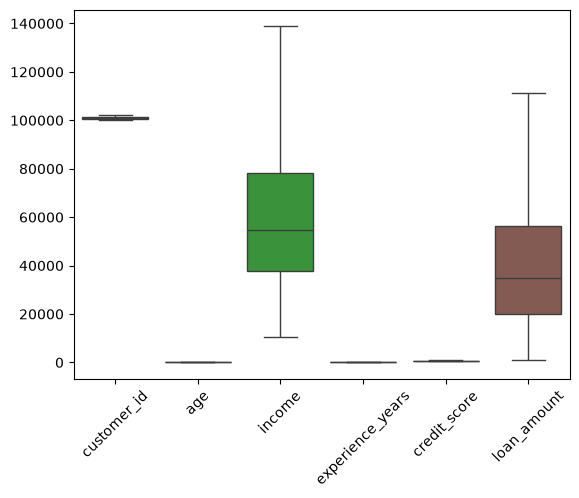

In [114]:
# check the outliers
sns.boxplot(df)
plt.xticks(rotation=45)

In [115]:
for col in num_cols:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)

    IQR=q3-q1

    LB=q1-1.5*IQR
    UB=q3+1.5*IQR

    df[col]=df[col].clip(lower=LB,upper=UB)

<Axes: >

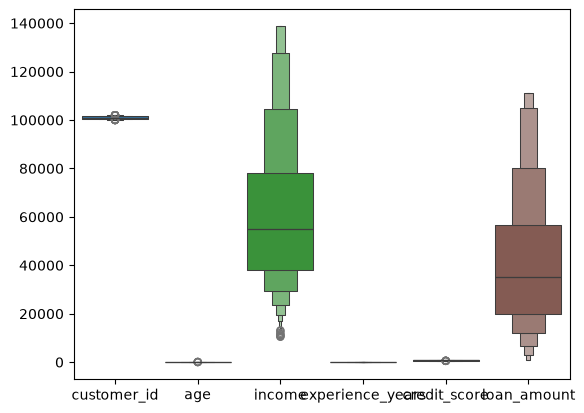

In [116]:
sns.boxenplot(df)

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'customer_id'),
  Text(1, 0, 'age'),
  Text(2, 0, 'income'),
  Text(3, 0, 'experience_years'),
  Text(4, 0, 'credit_score'),
  Text(5, 0, 'loan_amount')])

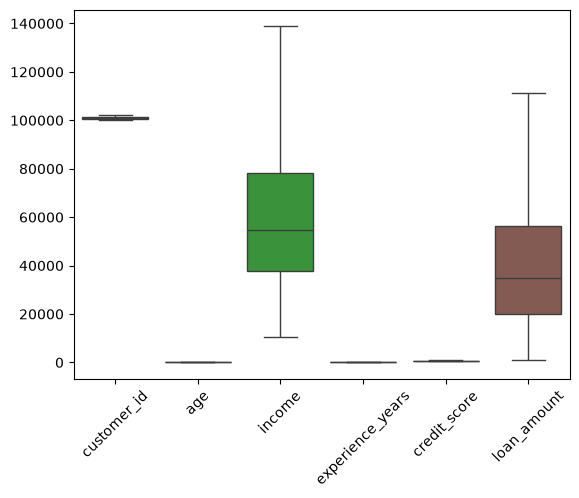

In [117]:
sns.boxplot(df)
plt.xticks(rotation=45)

# Model training

In [118]:
from sklearn.model_selection import train_test_split

X=df.drop(columns=["default","customer_id"])
y=df["default"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


In [119]:
# handel the imbalance

print(df["default"].value_counts())

default
No     1791
Yes     197
Name: count, dtype: int64


In [120]:
# check the percentage
df["default"].value_counts(normalize=True)*100

default
No     90.090543
Yes     9.909457
Name: proportion, dtype: float64

In [121]:
class_weight="balanced"

from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier(n_estimators=200,random_state=42,class_weight="balanced")

In [122]:
y_train.value_counts()

default
No     1432
Yes     158
Name: count, dtype: int64

### Random Over Sampling

In [123]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy="median"))
])

preprocessor=ColumnTransformer([
    (
        "cat",
        OneHotEncoder(handle_unknown="ignore",sparse_output=False),
        cat_cols
    ),(
        "num","passthrough",num_cols
    )

])

In [125]:
X_train_encoded=preprocessor.fit_transform(X_train)
X_test_encoded=preprocessor.transform(X_test)

In [ ]:
#%pip install imbalanced-learn

from imblearn.over_sampling import RandomOverSampler

ros=RandomOverSampler(
    random_state=42
)

X_train_ros,y_train_ros=ros.fit_resample(
    X_train_encoded,y_train
)

In [131]:
y_train_ros.value_counts()

default
No     1432
Yes    1432
Name: count, dtype: int64

In [143]:
rf_ros=RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_ros.fit(X_train_ros,y_train_ros)

RandomForestClassifier(n_estimators=200, random_state=42)

In [144]:
y_pred_ros=rf_ros.predict(X_test_encoded)

In [145]:
# Evaluation

from sklearn.metrics import accuracy_score

print("Accuracy: ",accuracy_score(y_test,y_pred_ros))

Accuracy:  0.9371859296482412


### SMOTE

In [135]:
from imblearn.over_sampling import SMOTE

smote=SMOTE(
    random_state=42
)

X_train_smote,y_train_smote=smote.fit_resample(
    X_train_encoded,y_train
)


c:\Users\vaish\anaconda3\envs\myenv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\vaish\anaconda3\envs\myenv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\vaish\anaconda3\envs\myenv\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\vaish\anaconda3\envs\myenv\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\vaish\anaconda3\envs\myenv\Lib\subprocess.py", line 1538, in 

In [136]:
y_train_smote.value_counts()


default
No     1432
Yes    1432
Name: count, dtype: int64

In [138]:
rf_smote=RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_smote.fit(X_train_smote,y_train_smote)

RandomForestClassifier(n_estimators=200, random_state=42)

In [139]:
y_pred_smote=rf_smote.predict(X_test_encoded)

In [141]:
print("Accuracy: ",accuracy_score(y_test,y_pred_smote))

Accuracy:  0.9221105527638191
